# 0. 문제 설명
- 해당 코드에서 주석 처리된 부분에 올바른 정답을 적어서 실행하시오

In [2]:
!pip install torchinfo==1.8.0 -q

# 1.모델에 필요한 class 구현
- 논문에서 언급된 연산은 코드 블록내에 구현되어있음
- 주석 설명 참조
- ResNet에 SE Block 붙여서 구현

In [3]:
import torch
from torch import nn
from torchinfo import summary

In [4]:
class SE_Block(nn.Module):
    def __init__(self, in_channels, reduction_ratio = 16):
        super().__init__()
        # 논문 Squeeze Operation에 해당
        self.squeeze = nn.AdaptiveAvgPool2d((1, 1))
        # 논문 Excitation Operation에 해당
        self.excitation = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction_ratio),
            nn.ReLU(inplace = True),
            nn.Linear(in_channels // reduction_ratio, in_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        se = self.squeeze(x) # Global Average Pooling
        se = se.reshape(x.shape[0], x.shape[1]) # Batch size축은 놔두고 나머지를 일렬로 쭉 펴기
        se = self.excitation(se)
        se = se.unsqueeze(dim = 2).unsqueeze(dim = 3) # 원래대로 복구
        out = se * x
        return out

class SE_Bottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_channels, inner_channels, stride = 1, projection = None):
        super().__init__()

        self.residual = nn.Sequential(
            nn.Conv2d(in_channels, inner_channels, 1, stride = stride, bias = False),
            nn.BatchNorm2d(inner_channels),
            nn.ReLU(inplace = True),
            nn.Conv2d(inner_channels, inner_channels, 3, padding = 1, bias = False),
            nn.BatchNorm2d(inner_channels),
            nn.ReLU(inplace = True),
            nn.Conv2d(inner_channels, inner_channels * self.expansion, 1, bias = False),
            nn.BatchNorm2d(inner_channels * self.expansion)
        )

        self.se_block = SE_Block(inner_channels * self.expansion)
        self.projection = projection
        self.relu = nn.ReLU(inplace = True)

    def forward(self, x):
        residual = self.residual(x)
        residual = self.se_block(residual)

        if self.projection is not None:
            skip_connection = self.projection(x)
        else:
            skip_connection = x

        out = self.relu(residual + skip_connection)
        return out


# 2. SENet 모델 layer 쌓기
- CIFAR-10이 32×32라서 conv1 stride=2 + maxpool stride=2 → 32×32가 8×8로 너무 빨리 줄어듦 -> conv1에서 maxpool 제거

In [5]:
class SE_ResNet(nn.Module):
    def __init__(self, block, num_blocks_list, n_classes = 1000):
        super().__init__()
        assert len(num_blocks_list) == 4

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size = 7, stride = 2, padding = 3, bias = False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace = True),
        )
        self.maxpool = nn.Identity() # maxpool 제거

        self.in_channels = 64
        self.stage1 = self.make_stage(block, 64, num_blocks_list[0], stride = 1)
        self.stage2 = self.make_stage(block, 128, num_blocks_list[1], stride = 2)
        self.stage3 = self.make_stage(block, 256, num_blocks_list[2], stride = 2)
        self.stage4 = self.make_stage(block, 512, num_blocks_list[3], stride = 2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, n_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)

        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


    def make_stage(self, block, inner_channels, num_blocks, stride = 1):
        if stride != 1 or self.in_channels != inner_channels * block.expansion:
            projection = nn.Sequential(
                nn.Conv2d(self.in_channels, inner_channels * block.expansion, 1, stride = stride, bias = False),
                nn.BatchNorm2d(inner_channels * block.expansion),
            )
        else:
            projection = None

        layers = []
        for idx in range(num_blocks):
            if idx == 0:
                layers.append(block(self.in_channels, inner_channels, stride, projection))
                self.in_channels = inner_channels * block.expansion
            else:
                layers.append(block(self.in_channels, inner_channels))
        return nn.Sequential(*layers)

SEResnet_50 구현

In [6]:
def se_resnet50():
    return SE_ResNet(SE_Bottleneck, [3, 4, 6, 3], n_classes=10) # 뒤에 사용할 데이터셋의 클래스는 10개

# 3. 훈련 코드

[데이터셋]
- CIFAR-10 사용 : 10개의 클래스, 학습 50,000개 & 테스트 10,000개
- T4 기준 6분정도 걸림

[training]
- T4 기준 10epoch 12분정도 걸림

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchinfo import summary

# cuda 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'Torchvision: {torchvision.__version__}')

# 데이터
data_path = './data'
transformation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])
val_transformation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

train_ds = datasets.CIFAR10(data_path, train=True, download=True, transform=transformation)
val_ds = datasets.CIFAR10(data_path, train=False, download=True, transform=val_transformation)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,
                      num_workers=2, pin_memory=True)  # CUDA 최적화
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False,
                    num_workers=2, pin_memory=True)

# 모델
model = se_resnet50().to(device)
summary(model, input_size=(1, 3, 32, 32))

loss_func = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3)

Using device: cuda
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


100%|██████████| 170M/170M [29:55<00:00, 95.0kB/s]


In [8]:
# training epoch
num_epochs = 10
best_loss = float('inf')

for epoch in range(num_epochs):
    # train
    model.train()
    train_loss, train_correct = 0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)  # 데이터 GPU로 이동
        pred = model(xb)
        loss = loss_func(pred, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        train_loss += loss.item()
        train_correct += (pred.argmax(1) == yb).sum().item()

    # val
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)  # 데이터 GPU로 이동
            pred = model(xb)
            val_loss += loss_func(pred, yb).item()
            val_correct += (pred.argmax(1) == yb).sum().item()

    train_loss /= len(train_dl)
    val_loss /= len(val_dl)
    train_acc = train_correct / len(train_ds)
    val_acc = val_correct / len(val_ds)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'se_resnet50_cifar10.pt')
        print('Best model saved!')

    lr_scheduler.step(val_loss)
    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | '
          f'train acc: {train_acc*100:.2f}% | val acc: {val_acc*100:.2f}%')

Best model saved!
Epoch 1/10 | train loss: 1.6930 | val loss: 1.3489 | train acc: 39.05% | val acc: 50.89%
Best model saved!
Epoch 2/10 | train loss: 1.2899 | val loss: 1.1698 | train acc: 53.61% | val acc: 58.87%
Best model saved!
Epoch 3/10 | train loss: 1.0638 | val loss: 1.1184 | train acc: 62.20% | val acc: 63.16%
Best model saved!
Epoch 4/10 | train loss: 0.8812 | val loss: 0.8125 | train acc: 68.94% | val acc: 72.06%
Best model saved!
Epoch 5/10 | train loss: 0.7696 | val loss: 0.7150 | train acc: 73.25% | val acc: 75.32%
Epoch 6/10 | train loss: 0.6970 | val loss: 0.7343 | train acc: 76.02% | val acc: 75.17%
Best model saved!
Epoch 7/10 | train loss: 0.6882 | val loss: 0.6663 | train acc: 76.18% | val acc: 77.78%
Best model saved!
Epoch 8/10 | train loss: 0.6439 | val loss: 0.6063 | train acc: 78.00% | val acc: 79.15%
Best model saved!
Epoch 9/10 | train loss: 0.5773 | val loss: 0.5687 | train acc: 80.18% | val acc: 80.66%
Best model saved!
Epoch 10/10 | train loss: 0.5245 | va

# 4. inference & 시각화

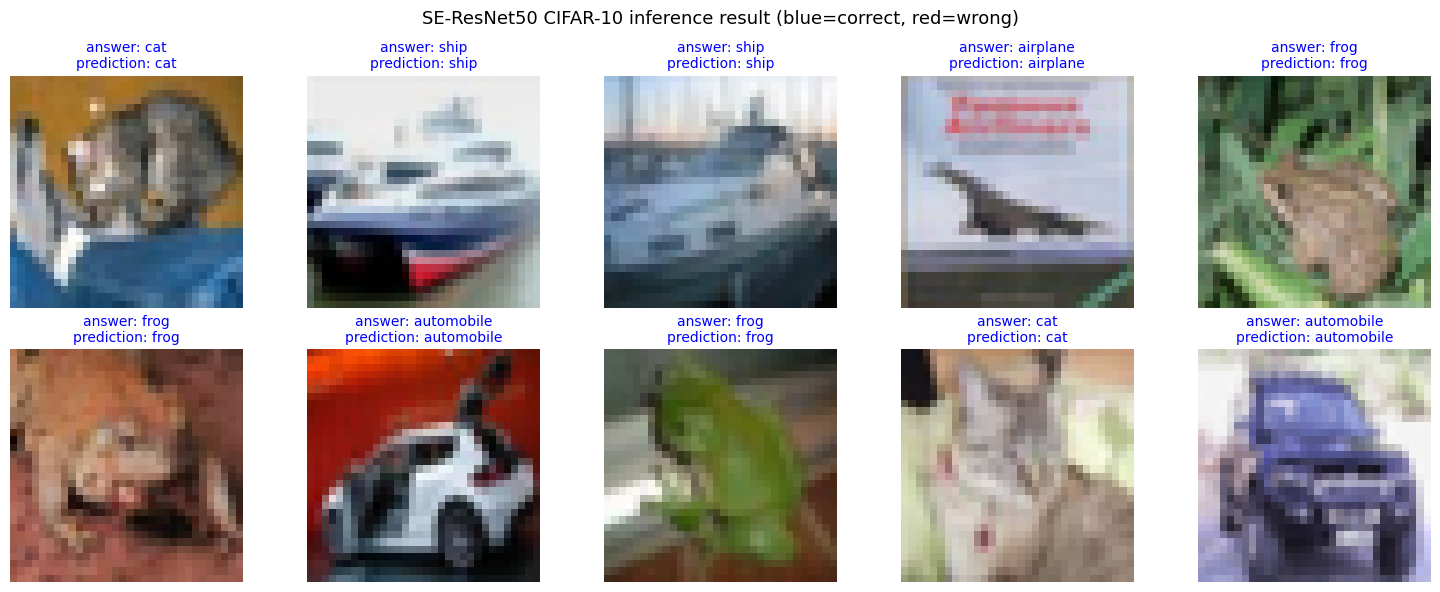

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# CIFAR-10 클래스 이름
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# inference & 시각화
def visualize_predictions(model, val_dl, num_images=10):
    model.eval()
    images, labels, preds = [], [], []

    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)
            pred = output.argmax(1)

            images.extend(xb.cpu())
            labels.extend(yb.cpu())
            preds.extend(pred.cpu())

            if len(images) >= num_images:
                break

    # 시각화
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    # Normalize 역변환
    mean = torch.tensor([0.4914, 0.4822, 0.4465])
    std = torch.tensor([0.2023, 0.1994, 0.2010])

    for i in range(num_images):
        img = images[i] * std[:, None, None] + mean[:, None, None]  # 역정규화
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        true_label = classes[labels[i]]
        pred_label = classes[preds[i]]
        correct = true_label == pred_label

        axes[i].imshow(img)
        axes[i].set_title(
            f'answer: {true_label}\nprediction: {pred_label}',
            color='blue' if correct else 'red',
            fontsize=10
        )
        axes[i].axis('off')

    plt.suptitle('SE-ResNet50 CIFAR-10 inference result (blue=correct, red=wrong)', fontsize=13)
    plt.tight_layout()
    plt.show()

# 훈련 끝나고 실행
visualize_predictions(model, val_dl, num_images=10)